In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
df = pd.read_csv("export/yelp_dish_mentions.csv")
df.head()


,review_id,user_id,business_id,stars_x,useful,funny,cool,text,date,name,city,stars_y,review_count,categories,mentioned_dish
0,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,Melt,New Orleans,4.0,32,"Sandwiches, Beer, Wine & Spirits, Bars, Food, ...",salad
1,pUycOfUwM8vqX7KjRRhUEA,59MxRhNVhU9MYndMkz0wtw,gebiRewfieSdtt17PTW6Zg,3.0,0,0,0,Had a party of 6 here for hibachi. Our waitres...,2016-07-25 07:31:06,Hibachi Steak House & Sushi Bar,Santa Barbara,3.5,488,"Steakhouses, Sushi Bars, Restaurants, Japanese",sushi
2,XW_LfMv0fV21l9c6xQd_lw,9OAtfnWag-ajVxRbUTGIyg,lj-E32x9_FA7GmUrBGBEWg,4.0,0,0,0,Love going here for happy hour or dinner! Gre...,2014-06-27 22:44:01,Brio Italian Grille,St Louis,3.5,366,"Bars, Pizza, Nightlife, Cocktail Bars, Italian...",pasta
3,OAhBYw8IQ6wlfw1owXWRWw,1C2lxzUo1Hyye4RFIXly3g,BVndHaLihEYbr76Z0CMEGw,5.0,0,0,0,"Great place for breakfast! I had the waffle, w...",2014-10-11 16:22:06,Mamas Kitchen,Tampa,4.5,162,"Sandwiches, Restaurants, American (New), Ameri...",fries
4,ZVvhc3Go7v5I8XTiVoWmqQ,WBpQDAZymU0dhIqXcACGNw,ut6fi2W2YaipNOqvi7e0jw,3.0,0,0,0,"Upland is a brewery based out of Bloomington, ...",2014-11-12 14:12:20,Upland Carmel Tap House,Carmel,4.0,244,"Nightlife, Food, Bars, Breweries, Pizza, Brewp...",pizza


C:\Users\Owner\AppData\Local\Temp\ipykernel_4680\2666005907.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_mentions.values, y=top_mentions.index, palette="viridis")


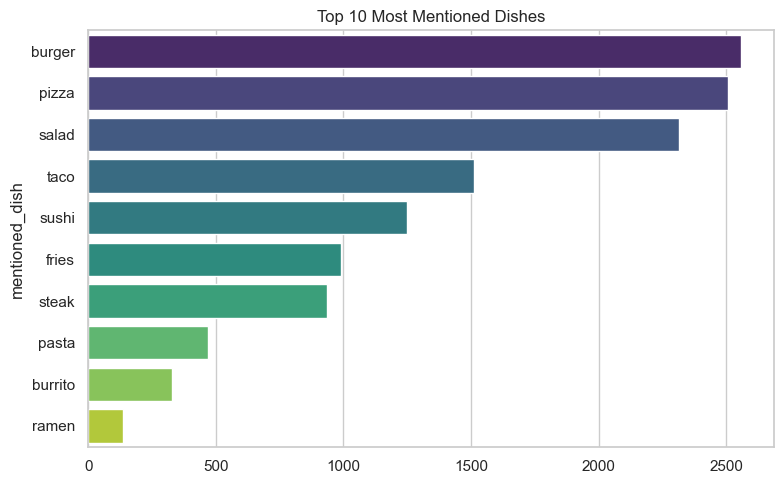

In [13]:
top_mentions = df["mentioned_dish"].value_counts().head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_mentions.values, y=top_mentions.index, palette="viridis")
plt.title("Top 10 Most Mentioned Dishes")
plt.tight_layout()
plt.show()



C:\Users\Owner\AppData\Local\Temp\ipykernel_4680\601593231.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=popular["avg_rating"], y=popular.index, palette="magma")


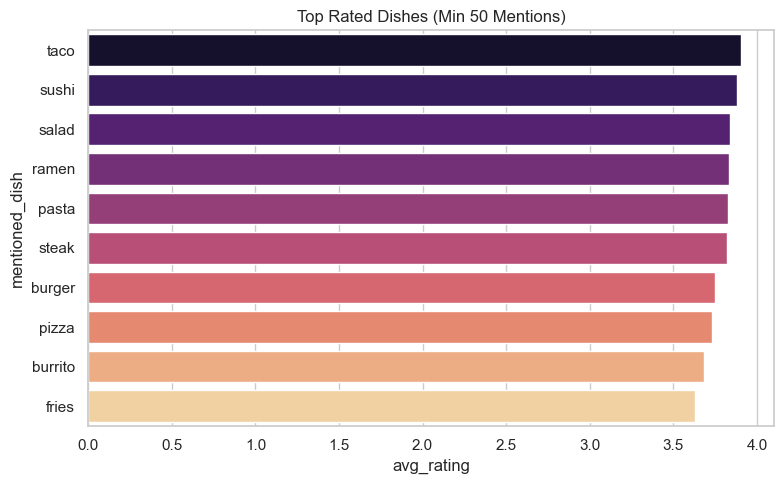

In [7]:
grouped = df.groupby("mentioned_dish").agg({
    "stars_x": ["mean", "count"]
})
grouped.columns = ["avg_rating", "mention_count"]

popular = grouped[grouped["mention_count"] >= 50].sort_values("avg_rating", ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=popular["avg_rating"], y=popular.index, palette="magma")
plt.title("Top Rated Dishes (Min 50 Mentions)")
plt.tight_layout()
plt.show()


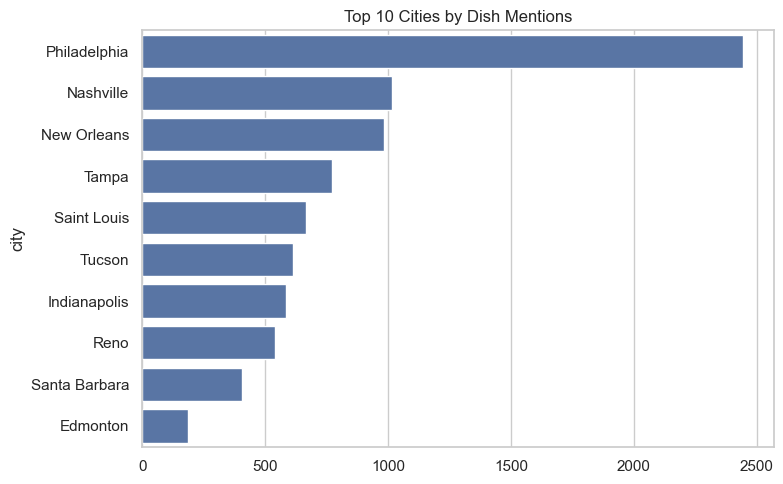

In [8]:
city_counts = df["city"].value_counts().head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=city_counts.values, y=city_counts.index)
plt.title("Top 10 Cities by Dish Mentions")
plt.tight_layout()
plt.show()


C:\Users\Owner\AppData\Local\Temp\ipykernel_4680\3918675269.py:17: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Owner\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


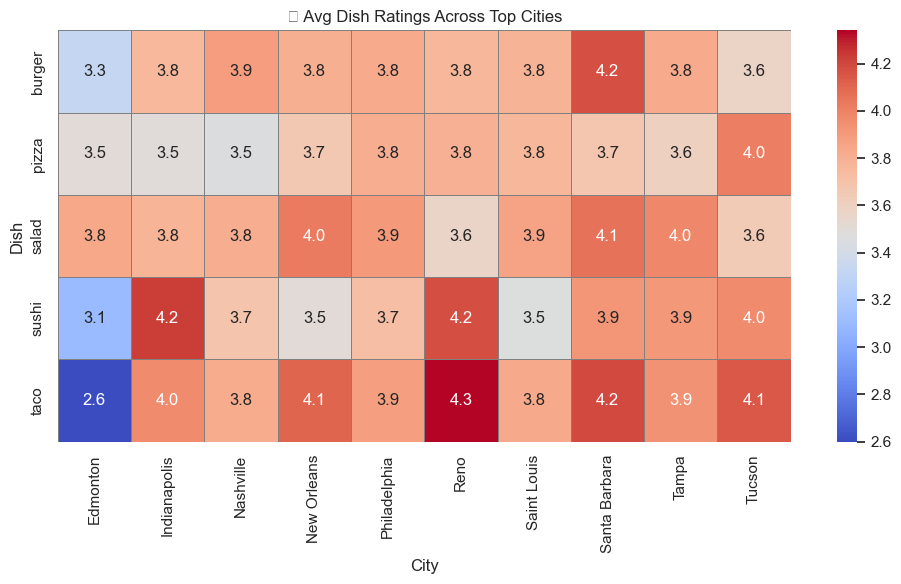

In [14]:
# Filter for top 5 dishes and top 10 cities (based on frequency)
top_dishes = df["mentioned_dish"].value_counts().head(5).index
top_cities = df["city"].value_counts().head(10).index

# Subset the data
heatmap_df = df[df["mentioned_dish"].isin(top_dishes) & df["city"].isin(top_cities)]

# Create pivot table
pivot = heatmap_df.groupby(["mentioned_dish", "city"])["stars_x"].mean().unstack().fillna(0)

# Plot
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="coolwarm", linewidths=0.5, linecolor='gray')
plt.title("🔥 Avg Dish Ratings Across Top Cities")
plt.xlabel("City")
plt.ylabel("Dish")
plt.tight_layout()
plt.show()


In [15]:
summary = grouped.reset_index().sort_values("mention_count", ascending=False)
summary.to_csv("export/dish_summary_powerbi.csv", index=False)
print("✅ Summary exported to Power BI file.")


✅ Summary exported to Power BI file.
